Data Visualisation Principals:

The aim of the notebook is to define what each plot does, what is appropriate data and plotting advantages/disadvantages.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [17]:
# Create a sample dataset for demonstration
data = {
    "Category": ["A", "B", "C", "D", "E"],
    "Values": [5, 15, 25, 20, 10],
    "Subcategory": ["X", "Y", "X", "Y", "X"],
    "Scores": [3.4, 2.1, 4.3, 3.8, 2.5]
}
df = pd.DataFrame(data)


In [18]:
# Additional dataset for continuous data
np.random.seed(42)
continuous_data = pd.DataFrame({
    "X": np.random.normal(size=100),
    "Y": np.random.normal(size=100),
    "Category": np.random.choice(["A", "B", "C"], size=100)
})

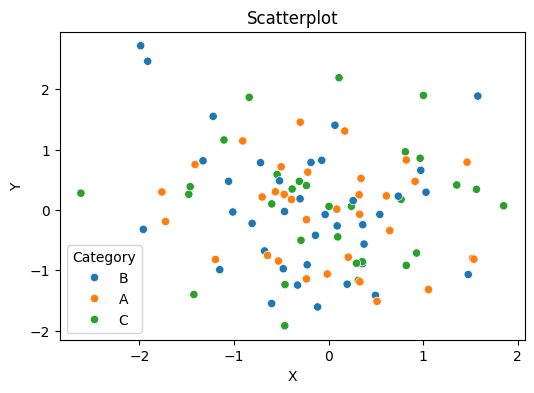

In [41]:
# 1. Scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(x="X", y="Y", data=continuous_data, hue="Category")
plt.title("Scatterplot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# Scatterplot Discussion:
# Use: Scatterplots are ideal for visualising the relationship or correlation between two continuous variables.
# They help in identifying patterns, trends, and potential outliers in the data.
# Limitations: When data points are densely packed, overplotting can obscure relationships, making it harder to interpret.
# Appropriate Data: Requires two continuous numerical variables. Adding a categorical variable as a hue can help distinguish groups.


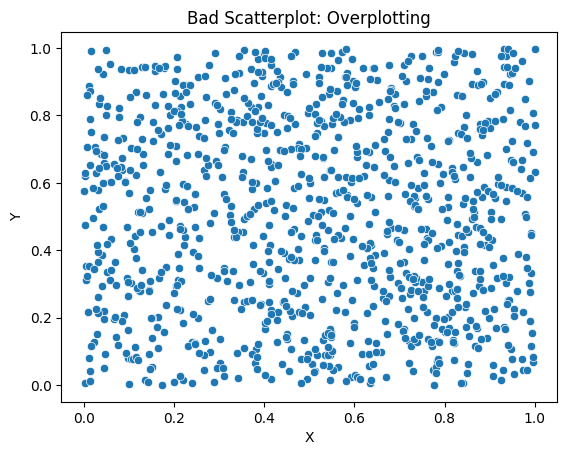

In [23]:
# Bad example
dense_data = pd.DataFrame({"X": np.random.rand(1000), "Y": np.random.rand(1000)})
sns.scatterplot(x="X", y="Y", data=dense_data)
plt.title("Bad Scatterplot: Overplotting")
plt.show()

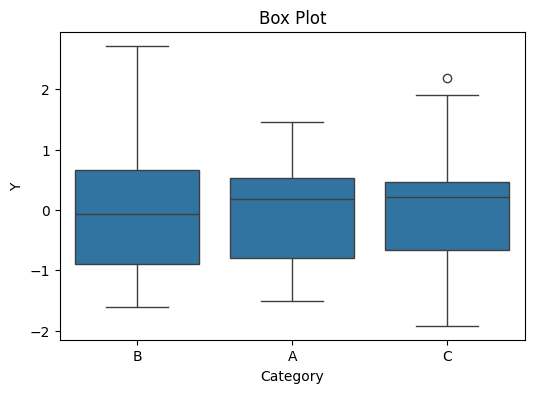

In [42]:
# 2. Box Plot
plt.figure(figsize=(6, 4))
sns.boxplot(x="Category", y="Y", data=continuous_data)
plt.title("Box Plot")
plt.show()

# Box Plot Discussion:
# Use: Box plots summarise the distribution of a dataset by showing the median, quartiles, and potential outliers.
# They are particularly useful for comparing distributions across multiple categories.
# Limitations: The simplicity of the box plot can sometimes hide nuances in the data, such as multi-modality.
# Appropriate Data: Works best for a continuous numerical variable grouped by a categorical variable.


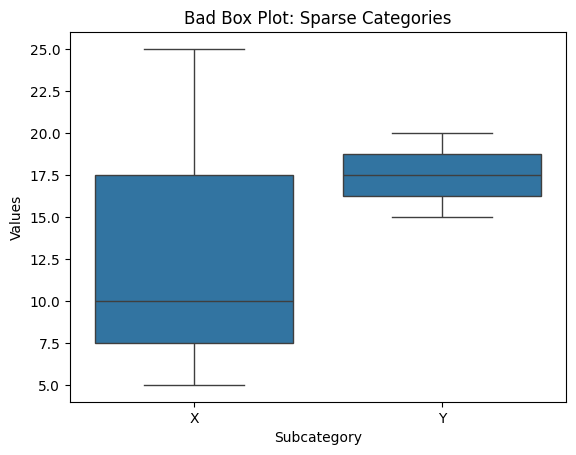

In [43]:
# Bad example
sns.boxplot(x="Subcategory", y="Values", data=df)

# Sparse categories
plt.title("Bad Box Plot: Sparse Categories")
plt.show()

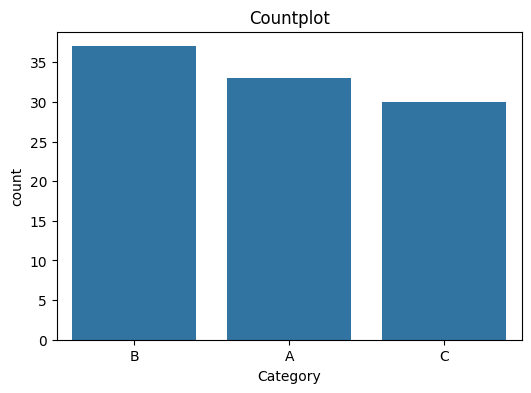

In [44]:
# 3. Countplot
plt.figure(figsize=(6, 4))
sns.countplot(x="Category", data=continuous_data)
plt.title("Countplot")
plt.show()

# Countplot Discussion:
# Use: Countplots are used to visualise the frequency of occurrences of categorical data.
# They provide a clear view of how many observations belong to each category.
# Limitations: It only shows absolute counts and does not account for proportions or percentages.
# Appropriate Data: Suitable for categorical variables.



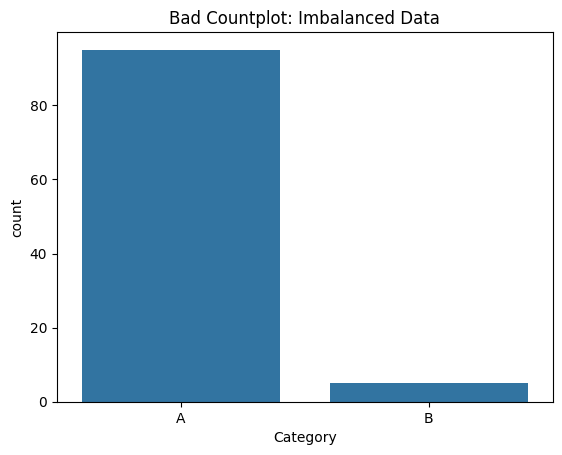

In [45]:
# Bad example
imbalanced_data = pd.DataFrame({"Category": ["A"] * 95 + ["B"] * 5})
sns.countplot(x="Category", data=imbalanced_data)
plt.title("Bad Countplot: Imbalanced Data")
plt.show()

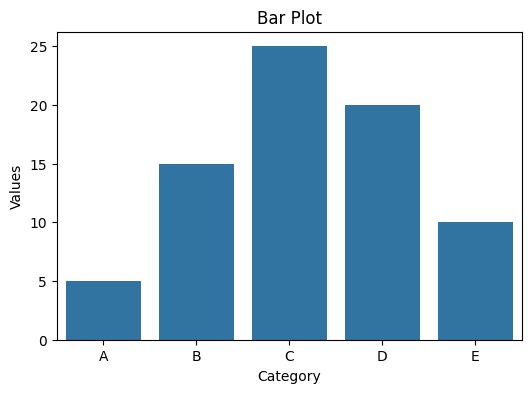

In [8]:
# 4. Bar Plot
plt.figure(figsize=(6, 4))
sns.barplot(x="Category", y="Values", data=df)
plt.title("Bar Plot")
plt.show()

# Bar Plot Discussion:
# Use: Bar plots display summary statistics (e.g., mean, median) of numerical data across different categories.
# They are effective for comparing metrics between groups.
# Limitations: Aggregating data into summary statistics can hide variability and individual data points.
# Appropriate Data: A categorical variable for the x-axis and a numerical variable for the y-axis.


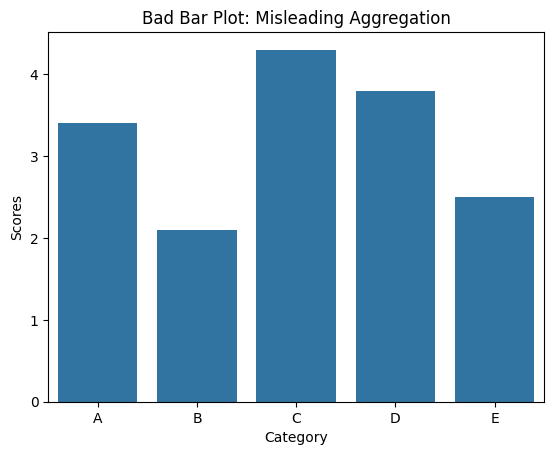

In [31]:
# Bad example
sns.barplot(x="Category", y="Scores", data=df)
# Scores are not aggregated
plt.title("Bad Bar Plot: Misleading Aggregation")
plt.show()

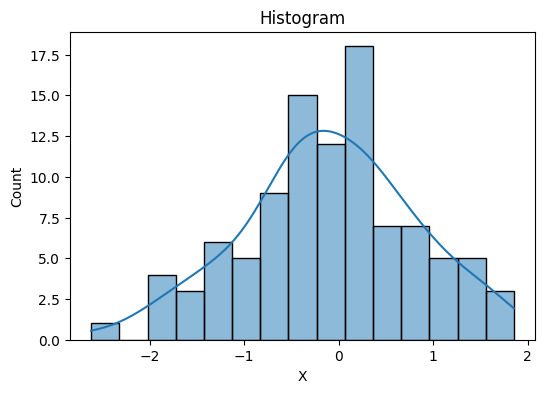

In [9]:
# 5. Histogram
plt.figure(figsize=(6, 4))
sns.histplot(continuous_data["X"], kde=True, bins=15)
plt.title("Histogram")
plt.show()

# Histogram Discussion:
# Use: Histograms display the distribution of a single numerical variable by dividing it into bins.
# They help in understanding the frequency of data points within specific ranges.
# Limitations: The choice of bin size can significantly impact interpretation; too many bins make it noisy, while too few oversimplify.
# Appropriate Data: A single continuous numerical variable.


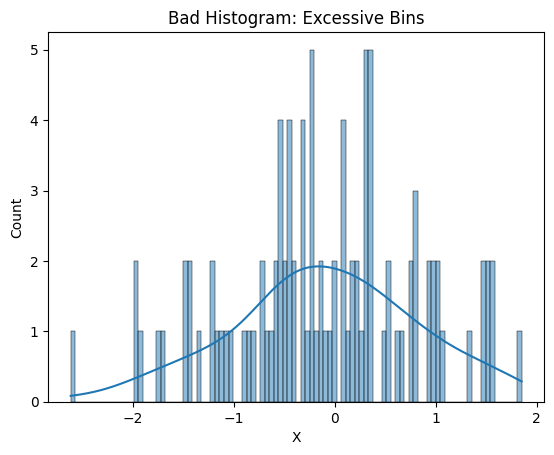

In [33]:
# Bad example
sns.histplot(continuous_data["X"], kde=True, bins=100)
plt.title("Bad Histogram: Excessive Bins")
plt.show()

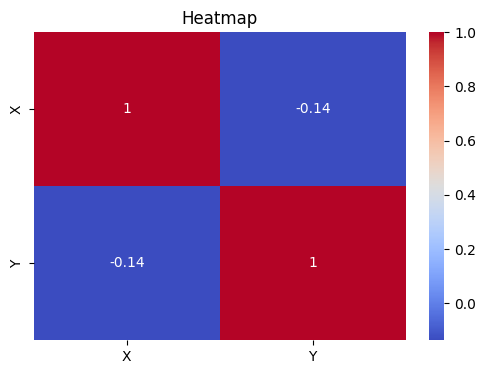

In [34]:
# Ensure only numerical columns are used
numerical_data = continuous_data.select_dtypes(include=[np.number])
correlation_matrix = numerical_data.corr()

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Heatmap")
plt.show()


# Heatmap Discussion:
# Use: Heatmaps are used to visualise relationships between numerical variables, often through a correlation matrix.
# They provide an intuitive way to identify strong positive or negative correlations.
# Limitations: Heatmaps can become overwhelming with too many variables or if correlations are weak and similar.
# Appropriate Data: Numerical variables in a tabular format or a pre-computed matrix like a correlation matrix.


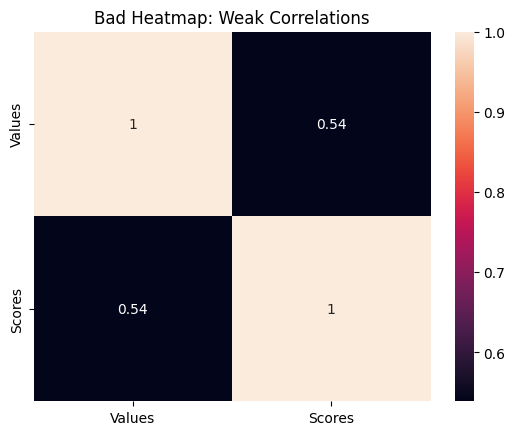

In [35]:
# Bad example
sns.heatmap(df.corr(numeric_only=True), annot=True)  # Sparse or uncorrelated data
plt.title("Bad Heatmap: Weak Correlations")
plt.show()

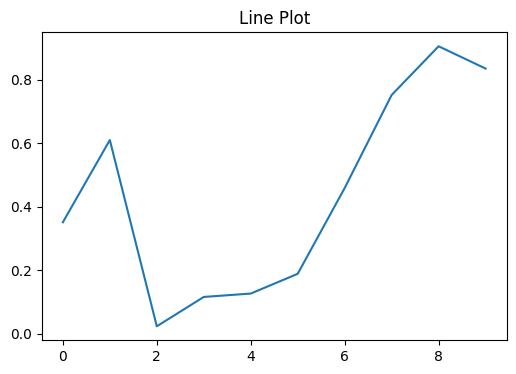

In [36]:
# 7. Line Plot
plt.figure(figsize=(6, 4))
sns.lineplot(x=range(10), y=np.random.rand(10))
plt.title("Line Plot")
plt.show()

# Line Plot Discussion:
# Use: Line plots are effective for showing trends over time or a continuous interval.
# They highlight changes and patterns in data over a sequence.
# Limitations: Assumes continuity between data points, which may not be accurate for discrete datasets.
# Appropriate Data: Sequential numerical data or time series data.


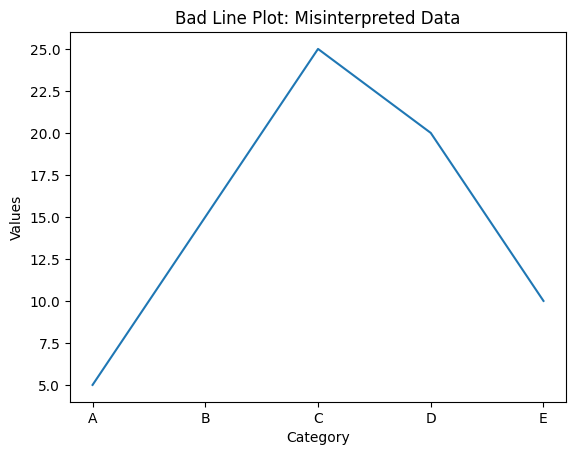

In [37]:
# Bad example
sns.lineplot(x="Category", y="Values", data=df)  # Categories are not continuous
plt.title("Bad Line Plot: Misinterpreted Data")
plt.show()

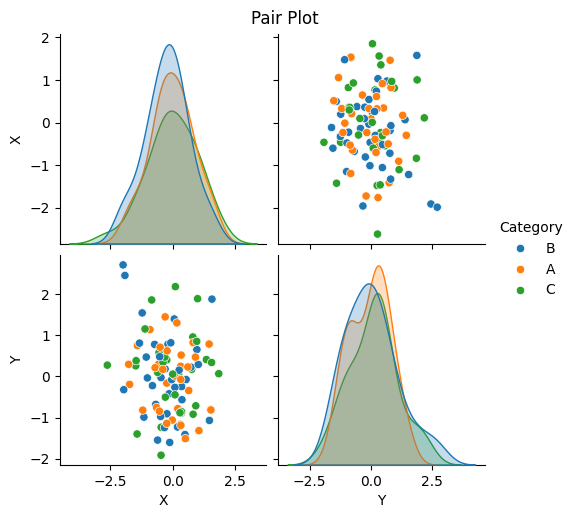

In [46]:
# 8. Pair Plot
sns.pairplot(continuous_data, hue="Category")
plt.suptitle("Pair Plot", y=1.02)
plt.show()

# Pair Plot Discussion:
# Use: Pair plots visualise pairwise relationships between numerical variables in a dataset.
# They are useful for initial exploratory data analysis to uncover correlations and group differences.
# Limitations: With too many variables, the plot can become cluttered and hard to interpret.
# Appropriate Data: Small datasets with a mix of numerical and categorical variables.


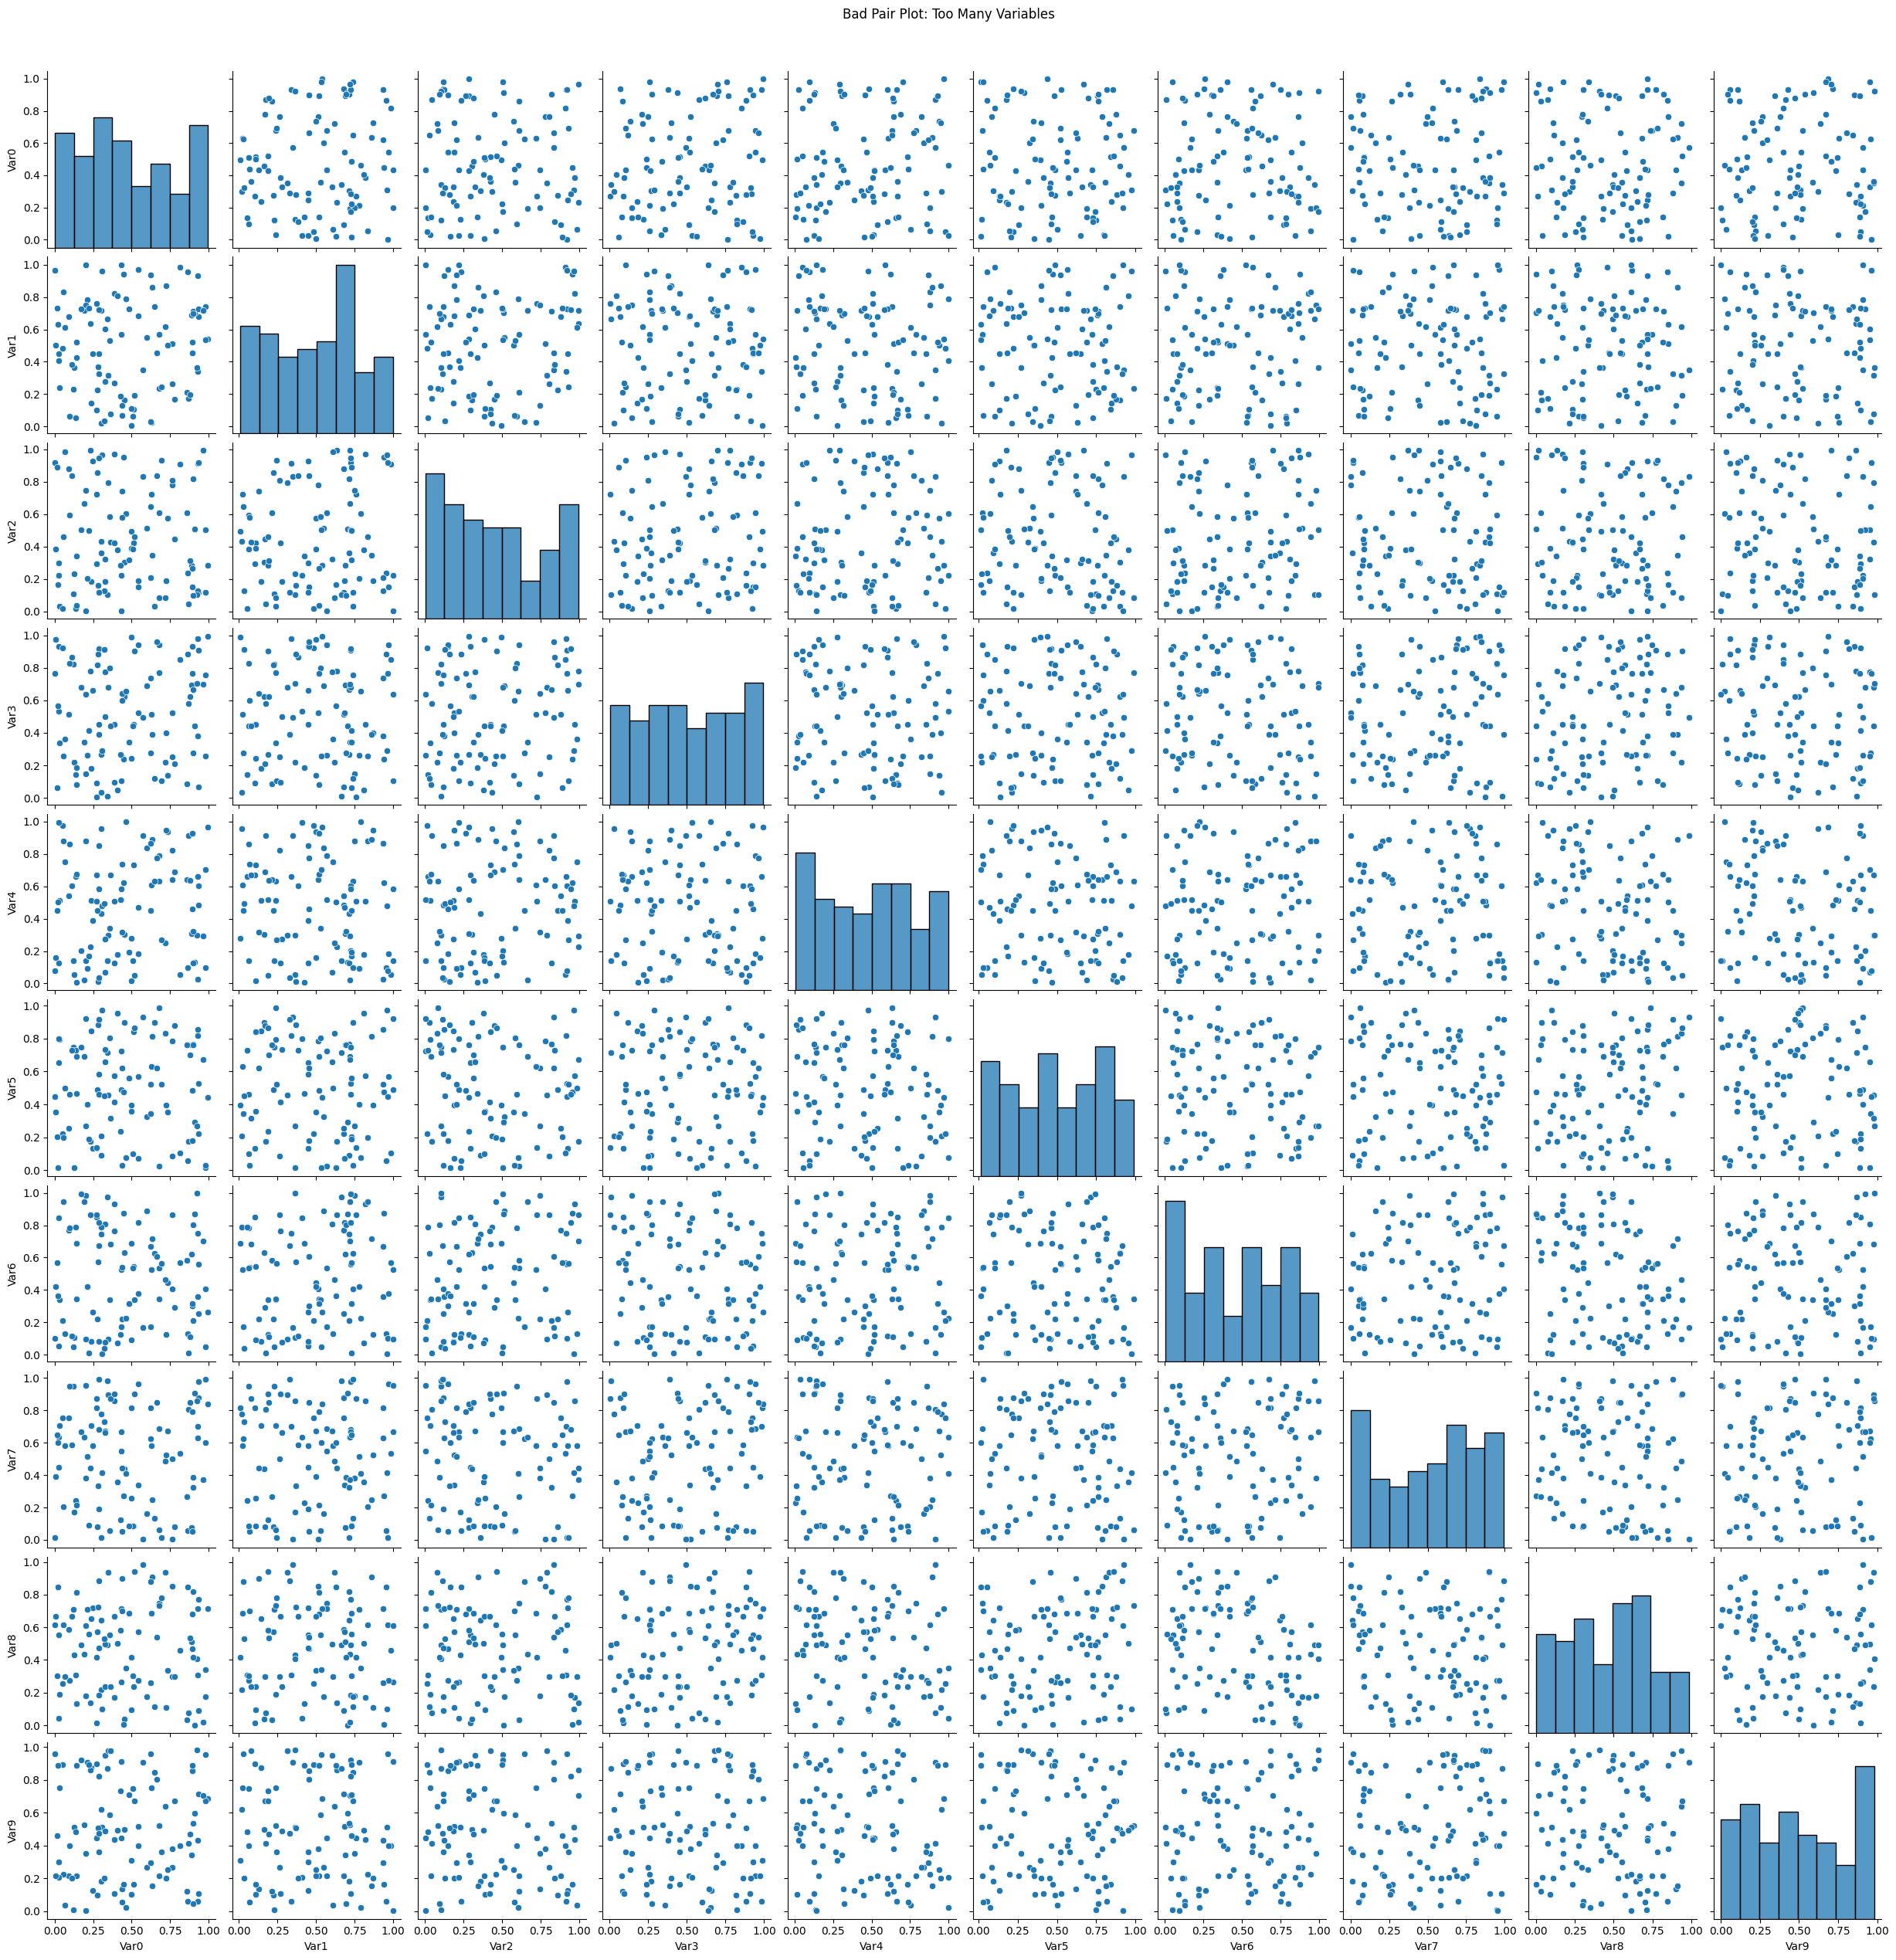

In [47]:
# Bad example
large_data = pd.DataFrame(np.random.rand(100, 10), columns=[f"Var{i}" for i in range(10)])
sns.pairplot(large_data)
plt.suptitle("Bad Pair Plot: Too Many Variables", y=1.02)
plt.show()

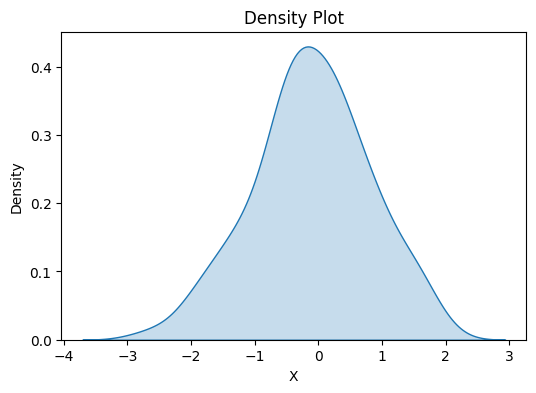

In [48]:
# 9. Density Plot
plt.figure(figsize=(6, 4))
sns.kdeplot(x="X", data=continuous_data, fill=True)
plt.title("Density Plot")
plt.show()

# Density Plot Discussion:
# Use: Density plots estimate the probability distribution of a continuous variable using kernel density estimation (KDE).
# They are smoother alternatives to histograms and can show overlapping distributions.
# Limitations: Overlapping distributions can make individual patterns harder to discern.
# Appropriate Data: One or more continuous numerical variables.


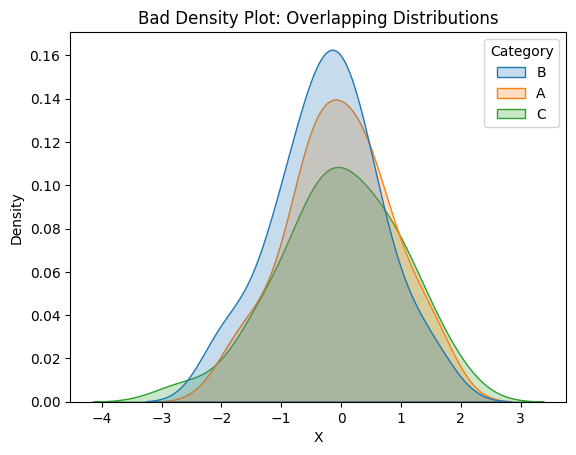

In [49]:
# Bad example
sns.kdeplot(x="X", data=continuous_data, hue="Category", fill=True)
plt.title("Bad Density Plot: Overlapping Distributions")
plt.show()